去重前的数据量: 20358
去重后的数据量: 19779
去除Gravatar ID后缺失值统计：
 用户ID               0
标签                 0
登录名                0
GitHub ID          0
节点ID               0
头像URL              0
API URL            0
HTML URL           0
粉丝URL              0
关注URL              0
Gists URL          0
Starred URL        0
订阅URL              0
组织URL              0
仓库URL              0
事件URL              0
接收事件URL            0
类型                 0
管理员                0
姓名              2589
公司              8982
博客             11263
位置              7080
电子邮件           11739
可雇佣            16481
简介             10930
Twitter用户名     14859
公共仓库数              0
公共Gists数           0
粉丝数                0
关注数                0
创建时间               0
更新时间               0
dtype: int64
处理后缺失值统计：
 用户ID               0
标签                 0
登录名                0
GitHub ID          0
节点ID               0
头像URL              0
API URL            0
HTML URL           0
粉丝URL              0
关注URL              0
Gists URL          0


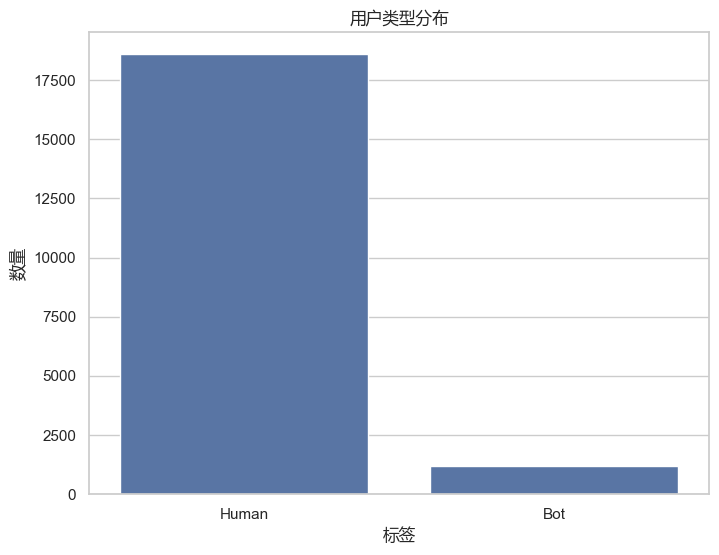


这是第4.2题的结果：机器人账号的创建日期


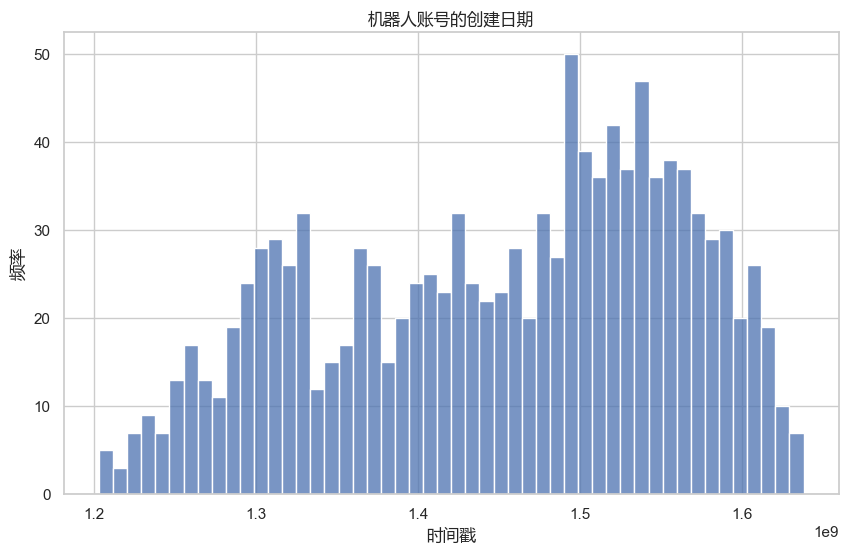


这是第4.3题的结果：人类账号的创建日期


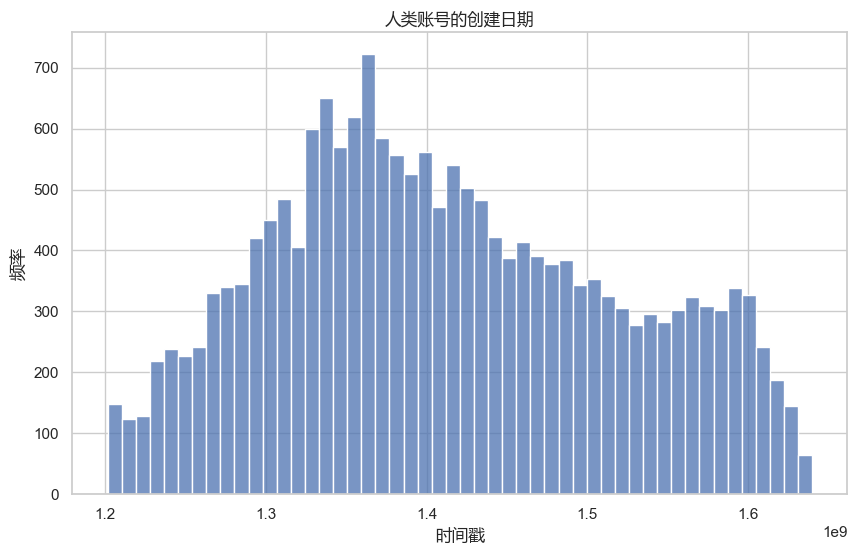


这是第4.4题的结果：机器人账号的粉丝与关注情况


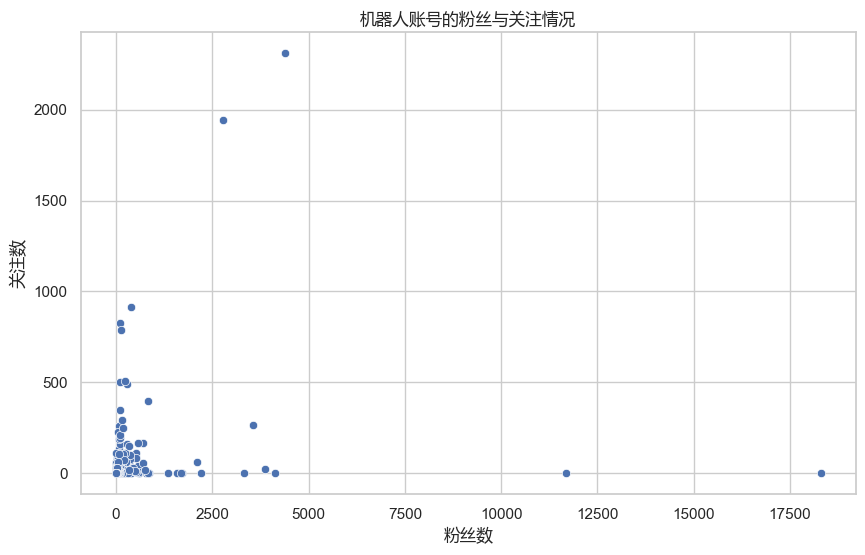


这是第4.5题的结果：人类账号的粉丝与关注情况


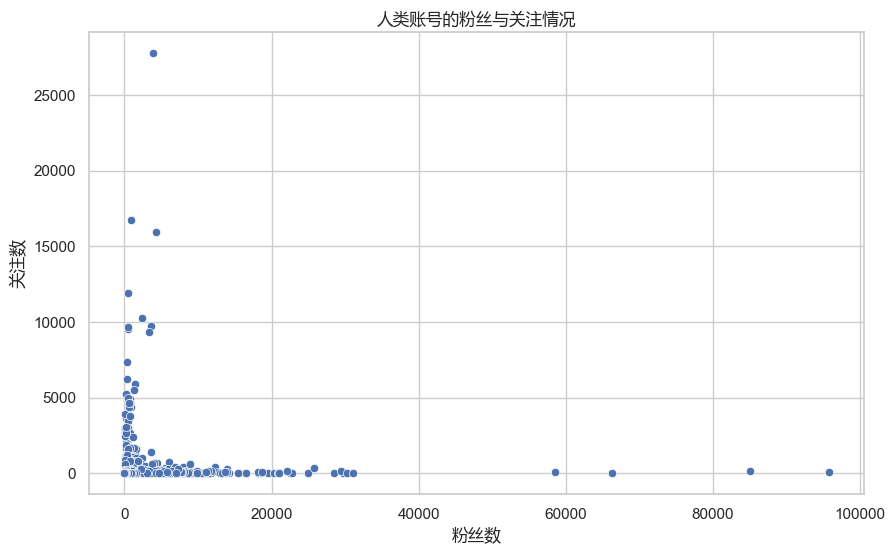

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import logging
from matplotlib.font_manager import FontProperties

# 设置日志级别为 ERROR 以抑制警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 尝试使用 Microsoft YaHei 字体
try:
    prop = FontProperties(family='Microsoft YaHei')  # 使用微软雅黑字体
except Exception as e:
    print("未能设置字体：", e)
    print("请确保已安装或提供正确的字体名称")
    exit()

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 使用微软雅黑显示中文
plt.rcParams['axes.unicode_minus'] = False             # 解决负号 '-' 显示为方块的问题

# 读取原始数据并转换列名
raw_data = pd.read_csv('github_bot_raw_data.csv')
columns = [
    '用户ID', '标签', '登录名', 'GitHub ID', '节点ID', '头像URL',
    'Gravatar ID', 'API URL', 'HTML URL', '粉丝URL', '关注URL',
    'Gists URL', 'Starred URL', '订阅URL', '组织URL',
    '仓库URL', '事件URL', '接收事件URL', '类型', '管理员',
    '姓名', '公司', '博客', '位置', '电子邮件', '可雇佣', '简介',
    'Twitter用户名', '公共仓库数', '公共Gists数', '粉丝数',
    '关注数', '创建时间', '更新时间'
]
data = raw_data.copy()
data.columns = columns

# 去除重复项
print(f"去重前的数据量: {len(data)}")
data = data.drop_duplicates()
print(f"去重后的数据量: {len(data)}")

# 删除 Gravatar ID 列并检查缺失值
data = data.drop('Gravatar ID', axis=1)
missing_values_before = data.isnull().sum()
print("去除Gravatar ID后缺失值统计：\n", missing_values_before)

# 转换布尔变量列
boolean_columns = ['公司', '位置', '电子邮件', '可雇佣']
for col in boolean_columns:
    data[col] = ~data[col].isnull()

# 文本数据用空字符串填充
text_columns = ['姓名', '简介', 'Twitter用户名']
data[text_columns] = data[text_columns].fillna('')

# 再次检查有无缺失值
missing_values_after = data.isnull().sum()
print("处理后缺失值统计：\n", missing_values_after)

# 将创建时间和更新时间转为时间戳
def to_timestamp(date_string):
    if pd.notna(date_string):
        return datetime.strptime(date_string, '%Y-%m-%dT%H:%M:%SZ').timestamp()
    else:
        return None

data['创建时间'] = data['创建时间'].apply(to_timestamp)
data['更新时间'] = data['更新时间'].apply(to_timestamp)

# 数据可视化
sns.set(style="whitegrid")

# 第4.1题结果
print("\n这是第4.1题的结果：用户类型分布")
plt.figure(figsize=(8,6))
ax = sns.countplot(x='标签', data=data)
ax.set_title('用户类型分布', fontproperties=prop)
ax.set_xlabel('标签', fontproperties=prop)
ax.set_ylabel('数量', fontproperties=prop)
plt.show()

# 第4.2题结果
bot_data = data[data['标签'] == 'Bot']
print("\n这是第4.2题的结果：机器人账号的创建日期")
plt.figure(figsize=(10,6))
ax = sns.histplot(bot_data['创建时间'], bins=50, kde=False)
ax.set_title('机器人账号的创建日期', fontproperties=prop)
ax.set_xlabel('时间戳', fontproperties=prop)
ax.set_ylabel('频率', fontproperties=prop)
plt.show()

# 第4.3题结果
human_data = data[data['标签'] == 'Human']
print("\n这是第4.3题的结果：人类账号的创建日期")
plt.figure(figsize=(10,6))
ax = sns.histplot(human_data['创建时间'], bins=50, kde=False)
ax.set_title('人类账号的创建日期', fontproperties=prop)
ax.set_xlabel('时间戳', fontproperties=prop)
ax.set_ylabel('频率', fontproperties=prop)
plt.show()

# 第4.4题结果
print("\n这是第4.4题的结果：机器人账号的粉丝与关注情况")
plt.figure(figsize=(10,6))
ax = sns.scatterplot(x='粉丝数', y='关注数', data=bot_data)
ax.set_title('机器人账号的粉丝与关注情况', fontproperties=prop)
ax.set_xlabel('粉丝数', fontproperties=prop)
ax.set_ylabel('关注数', fontproperties=prop)
plt.show()

# 第4.5题结果
print("\n这是第4.5题的结果：人类账号的粉丝与关注情况")
plt.figure(figsize=(10,6))
ax = sns.scatterplot(x='粉丝数', y='关注数', data=human_data)
ax.set_title('人类账号的粉丝与关注情况', fontproperties=prop)
ax.set_xlabel('粉丝数', fontproperties=prop)
ax.set_ylabel('关注数', fontproperties=prop)
plt.show()